In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [434]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [435]:
# Check the target variable's class balance
df['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

Only 15% of sessions ended in a purchase, meaning there'll be a need for a stratified train/test split when modeling, with class_weight='balanced', and metrics beyond accuracy will need to be evaluated.

In [436]:
# Check for duplicates
df.duplicated().sum()

np.int64(125)

There are 125 duplicates in the dataset, which need to be investigated before a decision on method of handling.

In [437]:
# Check if the duplicates have a class imbalance
df[df.duplicated(keep=False)]['Revenue'].value_counts(normalize=True)

Revenue
False    1.0
Name: proportion, dtype: float64

All 125 duplicates are for sessions that did not end in a purchase. Non-purchase sessions are likely to involve less eventful and less varied data such as number of administrative pages visited, if a user is quick to start and end a session without exploring the site.

In [438]:
# Look at the duplicated rows
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(25)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


Glancing at the data, there are no specific, unlikely values repeated across duplicated rows that indicate a problem with data collection. There is a trend among the duplicate rows that the session only includes one product page visited, with 0 administrative and 0 informational page visits, suggesting a legitimate, commonly repeated trend of a user seeing the product page and leaving the website without further browsing. These rows with the exact same values may still be distinct user sessions that exhibit very similar behavior.

In [439]:
# A more thorough check for oddly specific, duplicated values.
dup_rows = df[df.duplicated(keep=False)]
dup_groups = dup_rows.groupby(list(df.columns)).size().reset_index(name='count') # grouped by all columns being exactly the same
dup_groups = dup_groups.sort_values('count', ascending=False)
dup_groups.head(25)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,count
26,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False,14
36,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False,7
44,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,2,2,1,3,Returning_Visitor,False,False,7
38,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,1,3,Returning_Visitor,False,False,6
13,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,8,13,9,20,Other,False,False,5
34,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,1,1,Returning_Visitor,False,False,4
41,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,4,3,Returning_Visitor,False,False,4
60,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False,False,4
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False,3
3,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False,3


A majority of the duplicate sessions share the pattern of a user entering and leaving the website, leading to default bounce rate, exit rate, and page value metrics, visiting 0 administrative and 0 information pages, and not making a purchase. The duplicate sessions are believable, with no unrealistic values that would indicate the same same user's session showing up twice.

In [440]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [441]:
# Check bounce rate value if no pages were visited
# Are there sessions where no pages were visited?

df_check = df[df['Administrative'] + df['Informational'] + df['ProductRelated'] == 0]
df_check

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2683,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,3,2,3,18,Returning_Visitor,True,False
3187,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,2,2,8,3,Returning_Visitor,False,False
5557,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,3,Returning_Visitor,False,False
5800,0,0.0,0,0.0,0,0.0,0.18,0.181818,0.0,0.0,June,2,2,7,6,Returning_Visitor,False,False
8052,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,2,Returning_Visitor,False,False
11865,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,8,8,Returning_Visitor,False,False


There are 6 rows where no pages were visited. It's unclear why these sessions exist in the dataset, and will be dropped.

In [442]:
# VisitorType is a string
df['VisitorType'].unique()

<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

In [443]:
df['VisitorType'].value_counts(normalize=True) * 100

VisitorType
Returning_Visitor    85.571776
New_Visitor          13.738848
Other                 0.689376
Name: proportion, dtype: float64

In [444]:
pct = df[df['Revenue'] == True]['VisitorType'].value_counts(normalize=True) * 100
print(pct)

VisitorType
Returning_Visitor    77.044025
New_Visitor          22.117400
Other                 0.838574
Name: proportion, dtype: float64


While new visitors made up only 13% of all visitors, they made up 22% of sessions that ended with a purchase.

Make a feature 'is_returning_visitor'

In [445]:
df.shape

(12330, 18)

In [446]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [447]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


For page durations - units (seconds vs minutes) were not specified in the metadata. An intuitive guess would be that the duration is represented in seconds, as half of the sessions included a duration of 598 for a product related page, which, if representing seconds, is 10 minutes- and for 75% of product page visits- ~1464 seconds (~24 minutes) or less per session. However whether duration for pages is indeed in seconds cannot be concretely confirmed at this time.

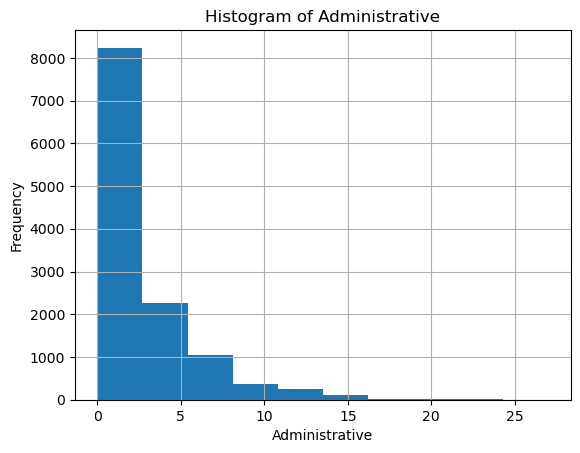

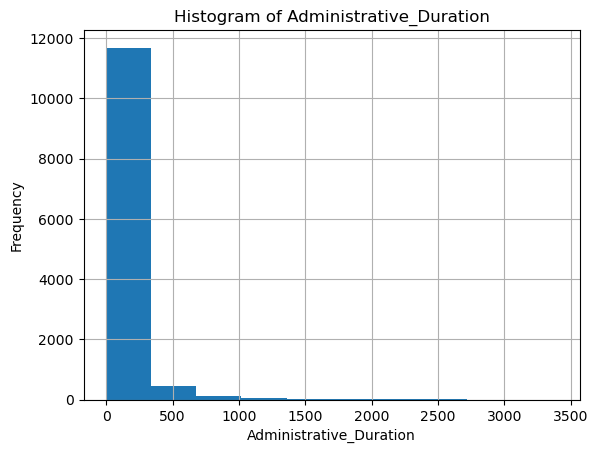

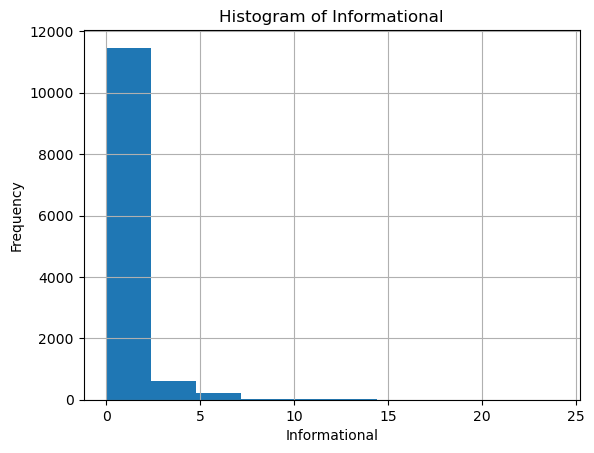

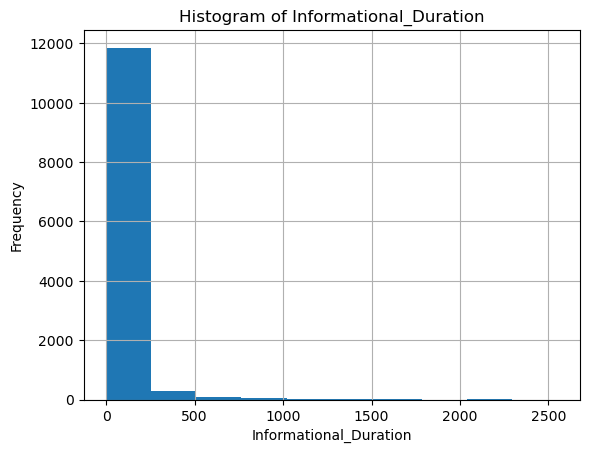

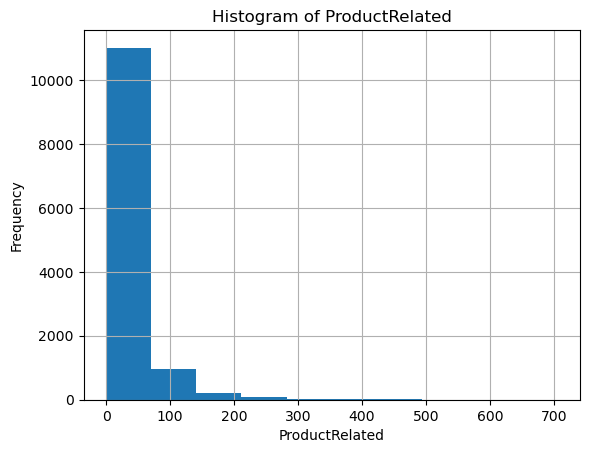

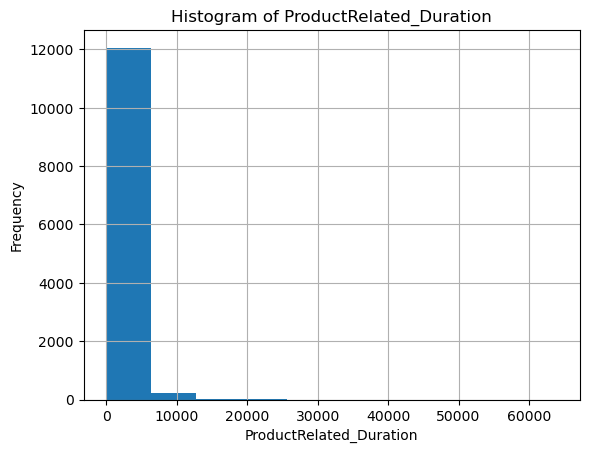

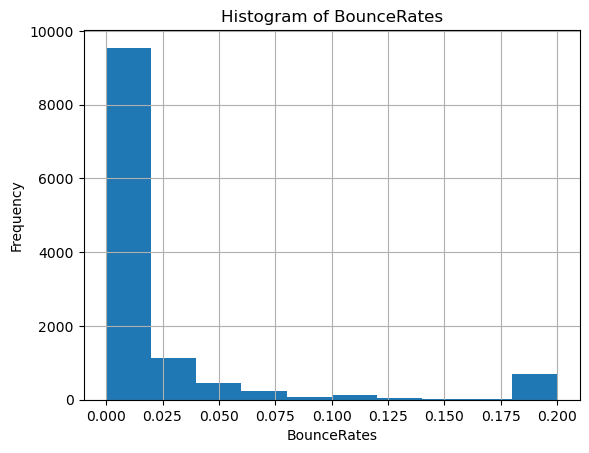

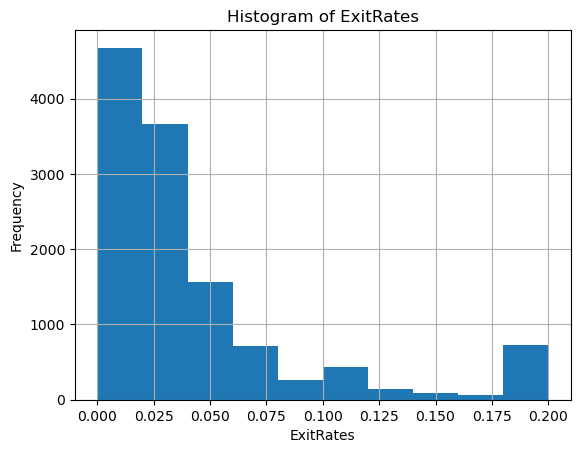

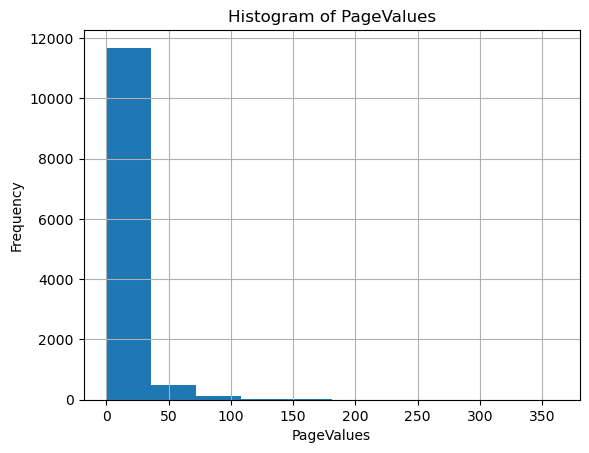

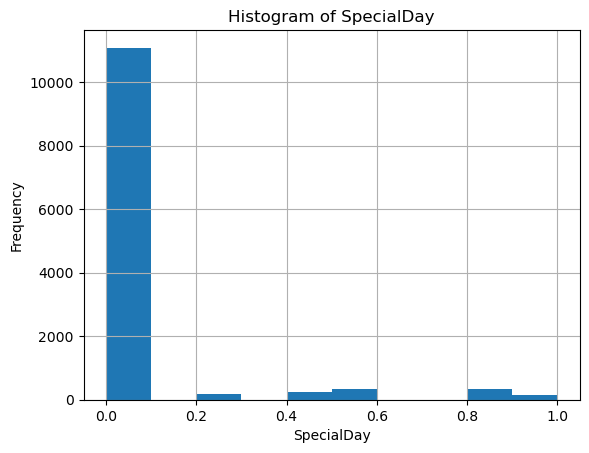

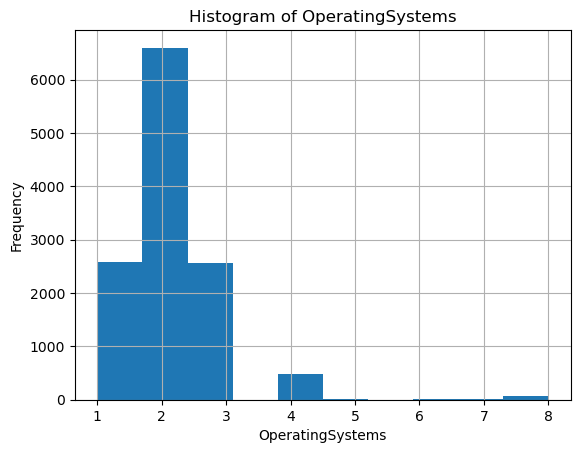

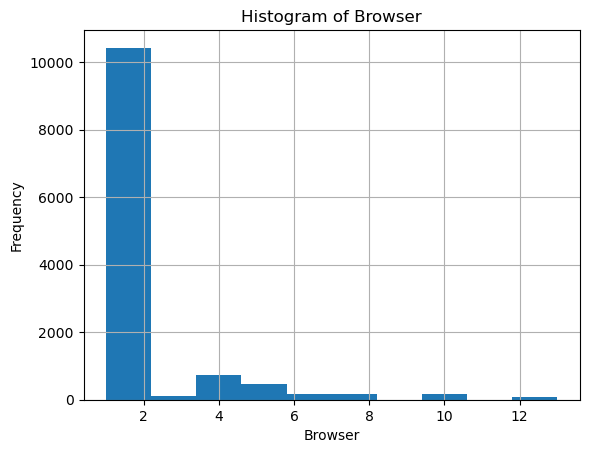

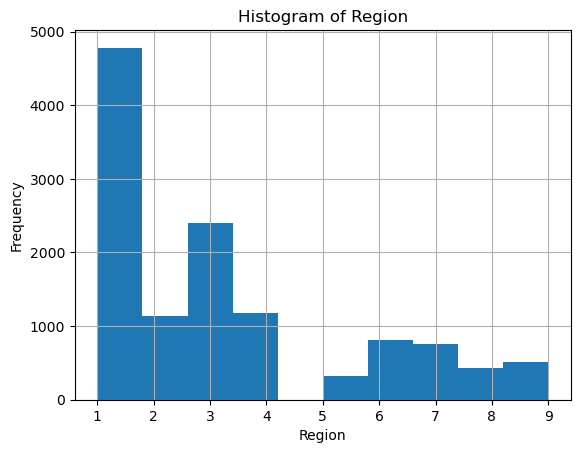

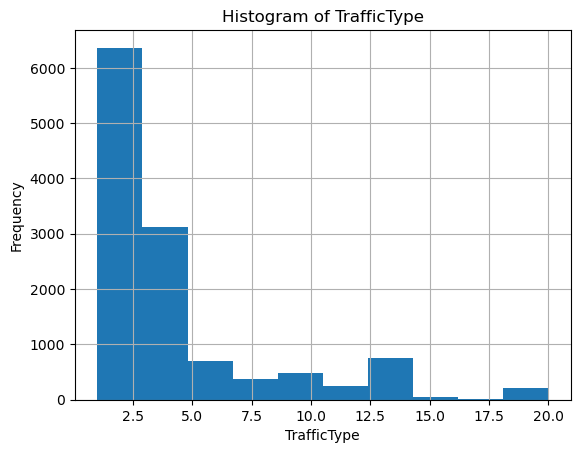

In [448]:
for c in df:
    if c in df.describe():
        plt.figure()
        df[c].hist()
        plt.title(f"Histogram of {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")

In [449]:
# Check all outliers for ProductRelated_Duration
q1 = df['ProductRelated_Duration'].quantile(0.25)
q3 = df['ProductRelated_Duration'].quantile(0.75)
IQR = q3 - q1

lower_boundary = q1 - 1.5 * IQR
upper_boundary = q3 + 1.5 * IQR

outliers = df[(df['ProductRelated_Duration'] < lower_boundary) | (df['ProductRelated_Duration'] > upper_boundary)]
outliers.shape

(961, 18)

In [450]:
upper_outliers = df[(df['ProductRelated_Duration'] > upper_boundary)]
upper_outliers.shape

(961, 18)

In [451]:
# Check how many of these sessions led to a purchase
outliers['Revenue'].value_counts(normalize=True)

Revenue
False    0.699272
True     0.300728
Name: proportion, dtype: float64

While 15% of all original sessions ended with a purchase, abnormaly long sessions identified in the 961 outliers showed a doubled rate of a purchase being made - at 30%.

Adding onto that, removing these 961 outliers would reduce a sizable chunk of the data, including hundreds with generated revenue, exasperating the class imbalance even further.

In [452]:
# Investigate the highest duration outliers
outliers = outliers.sort_values('ProductRelated_Duration', ascending=False).reset_index()
outliers.head(20)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,8071,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
1,5152,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,May,2,2,1,14,Returning_Visitor,True,False
2,9238,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
3,8784,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,1,1,1,2,Returning_Visitor,False,True
4,8308,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,2,4,3,8,Returning_Visitor,False,False
5,7662,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,2,2,4,13,Returning_Visitor,False,False
6,6684,20,199.456273,7,299.033333,686,23342.08205,0.009853,0.022771,0.150650,0.0,Aug,2,2,1,1,Returning_Visitor,False,False
7,6165,10,2407.423810,3,434.300000,486,23050.10414,0.000324,0.011249,0.000000,0.0,Jul,2,2,1,3,Returning_Visitor,False,False
8,5916,12,245.733333,4,1511.700000,439,21857.04648,0.003589,0.012498,11.439233,0.0,Sep,2,2,1,13,Returning_Visitor,False,False
9,8972,11,631.416667,5,1037.150000,501,21672.24425,0.003965,0.014292,9.131387,0.0,Nov,2,2,1,2,Returning_Visitor,False,True


row 1 - 17.8 hrs of browsing
row 2 - 12 hrs of browsing
row 3 - 8.3 hrs of browsing

These 3 sessions are distinct in that not only are browsing times very long, but they also did not lead to a purchase. These sessions may indicate bot activity, and should be dropped to reduce noise.

The session below them did end in a purchase, and from there it's less clear whether they are actual sessions that a user continued to engage in throughout 7 hours of having the tab open, but continuing to explore the website.

In [453]:
df['ProductRelated_Duration'].describe()

count    12330.000000
mean      1194.746220
std       1913.669288
min          0.000000
25%        184.137500
50%        598.936905
75%       1464.157214
max      63973.522230
Name: ProductRelated_Duration, dtype: float64

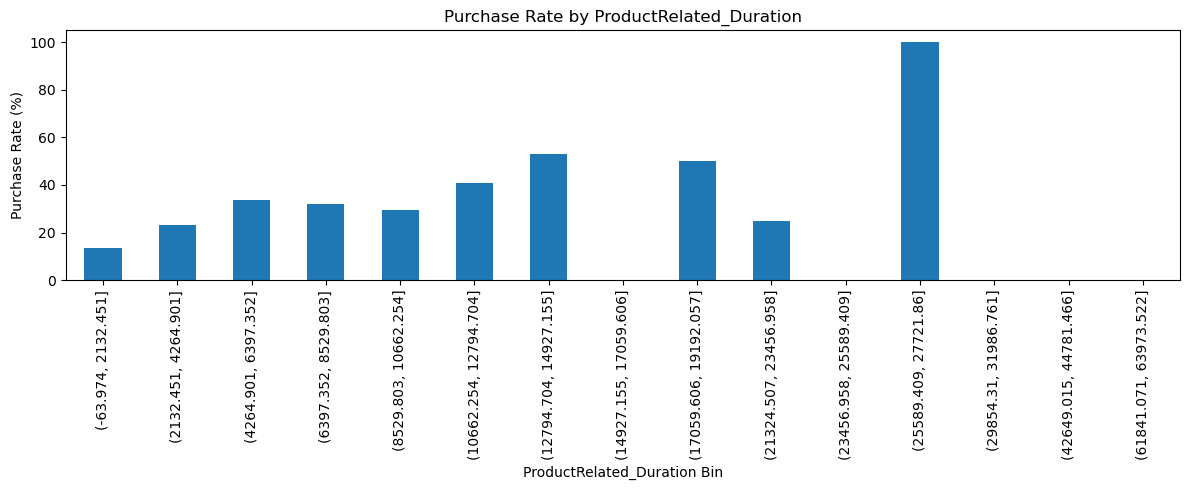

duration_bin
(-63.974, 2132.451]       10394
(2132.451, 4264.901]       1308
(4264.901, 6397.352]        358
(6397.352, 8529.803]        134
(8529.803, 10662.254]        68
(10662.254, 12794.704]       32
(12794.704, 14927.155]       17
(14927.155, 17059.606]        5
(17059.606, 19192.057]        4
(21324.507, 23456.958]        4
(23456.958, 25589.409]        2
(25589.409, 27721.86]         1
(29854.31, 31986.761]         1
(42649.015, 44781.466]        1
(61841.071, 63973.522]        1
dtype: int64

In [454]:
df['duration_bin'] = pd.cut(df['ProductRelated_Duration'], bins=30)

bin_purchase_rate = df.groupby('duration_bin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_bin').size()

fig, ax = plt.subplots(figsize=(12, 5))
bin_purchase_rate.plot(kind='bar', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('ProductRelated_Duration Bin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by ProductRelated_Duration')
plt.tight_layout()
plt.show()
bin_counts


Bin 12794.704 - 14927.155 equals a range of about 3.55 - 4.15 hours, with 17 sessions. 
Bins after this one only have 1-5 sessions, providing too little data to draw conclusions from.
17 is still too small of a session sample amount to reliably cap duration at this bin's maximum. 
Most sessions land in the first bin, then the second, so this chart does not reliably show where rate plateaus. I'll have to make bins where each has a comparable size of sessions to draw more reliable conclusions.

Editing note: after further exploration - duration is not 'per-page' here - but a total across all product pages visited in a session. Further into the EDA I look at average 'per-page' viewing durations.

In [455]:
df['duration_qbin'] = pd.qcut(df['ProductRelated_Duration'], q=15)
qbin_purchase_rate = df.groupby('duration_qbin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_qbin').size()
bin_counts

duration_qbin
(-0.001, 8.0]            825
(8.0, 63.658]            819
(63.658, 129.0]          824
(129.0, 203.399]         820
(203.399, 293.472]       822
(293.472, 402.117]       822
(402.117, 529.314]       822
(529.314, 675.911]       822
(675.911, 852.0]         823
(852.0, 1087.795]        821
(1087.795, 1375.831]     822
(1375.831, 1775.929]     822
(1775.929, 2408.611]     822
(2408.611, 3708.385]     822
(3708.385, 63973.522]    822
dtype: int64

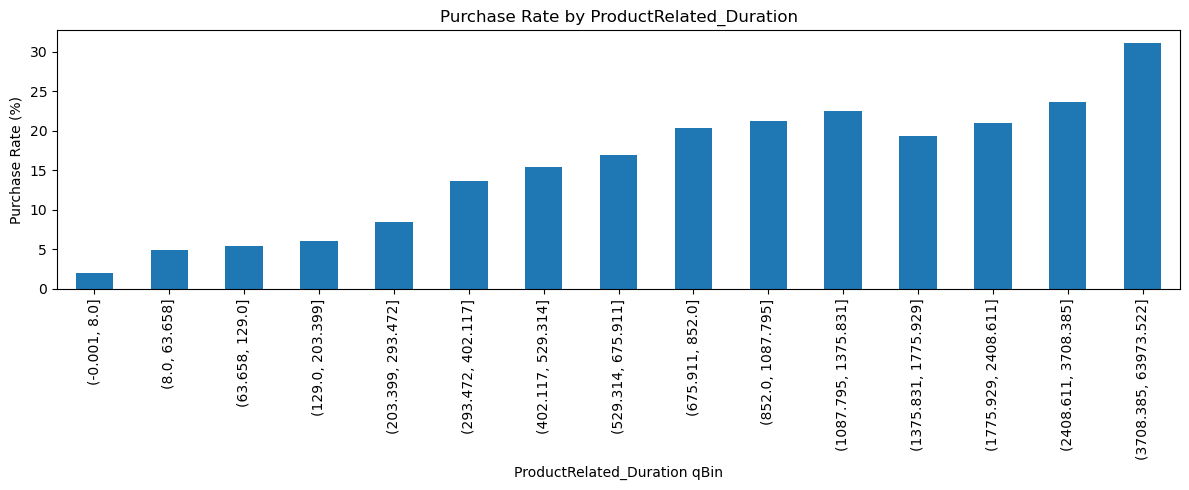

duration_qbin
(-0.001, 8.0]            825
(8.0, 63.658]            819
(63.658, 129.0]          824
(129.0, 203.399]         820
(203.399, 293.472]       822
(293.472, 402.117]       822
(402.117, 529.314]       822
(529.314, 675.911]       822
(675.911, 852.0]         823
(852.0, 1087.795]        821
(1087.795, 1375.831]     822
(1375.831, 1775.929]     822
(1775.929, 2408.611]     822
(2408.611, 3708.385]     822
(3708.385, 63973.522]    822
dtype: int64

In [456]:
fig, ax = plt.subplots(figsize=(12, 5))
qbin_purchase_rate.plot(kind='bar', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('ProductRelated_Duration qBin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by ProductRelated_Duration')
plt.tight_layout()
plt.show()
bin_counts

The final bin has a 60k range compared to the bin before it with a 1.3k range - a 46x difference.

In [457]:
df['mean_product_duration'] = df['ProductRelated_Duration'] / df['ProductRelated']
df['mean_product_duration'].describe()

count    12292.000000
mean        37.750032
std         44.788059
min          0.000000
25%         17.731942
50%         28.978266
75%         45.123375
max       1411.000000
Name: mean_product_duration, dtype: float64

In [458]:
df['duration_qbin'] = pd.qcut(df['mean_product_duration'], q=15)
qbin_purchase_rate = df.groupby('duration_qbin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_qbin').size()
bin_counts

duration_qbin
(-0.001, 4.0]       821
(4.0, 11.515]       818
(11.515, 15.376]    820
(15.376, 18.449]    819
(18.449, 21.445]    820
(21.445, 24.298]    819
(24.298, 27.372]    819
(27.372, 30.575]    820
(30.575, 34.131]    819
(34.131, 38.446]    820
(38.446, 43.597]    819
(43.597, 50.8]      819
(50.8, 61.811]      820
(61.811, 84.413]    819
(84.413, 1411.0]    820
dtype: int64

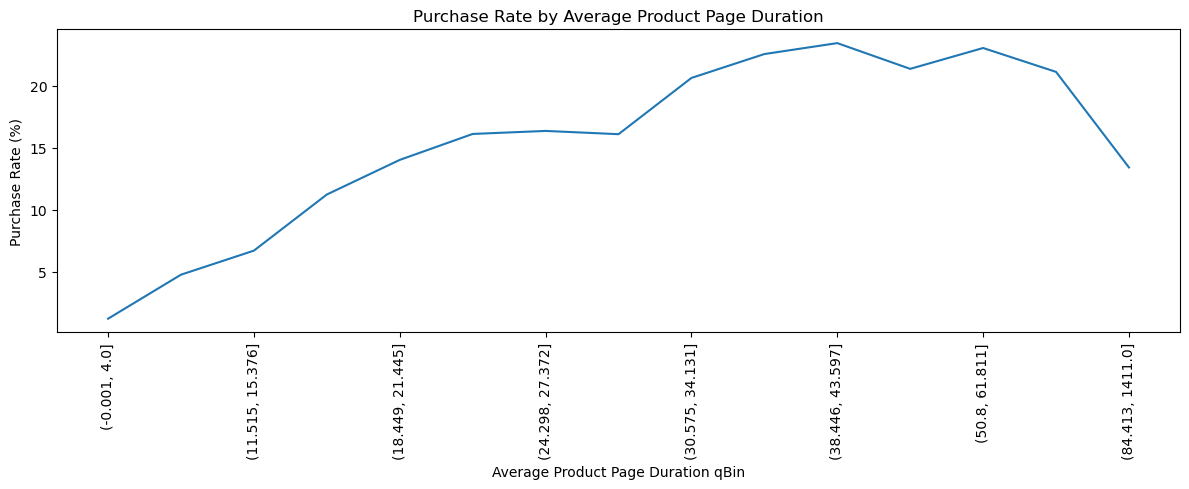

duration_qbin
(-0.001, 4.0]       821
(4.0, 11.515]       818
(11.515, 15.376]    820
(15.376, 18.449]    819
(18.449, 21.445]    820
(21.445, 24.298]    819
(24.298, 27.372]    819
(27.372, 30.575]    820
(30.575, 34.131]    819
(34.131, 38.446]    820
(38.446, 43.597]    819
(43.597, 50.8]      819
(50.8, 61.811]      820
(61.811, 84.413]    819
(84.413, 1411.0]    820
dtype: int64

In [459]:
fig, ax = plt.subplots(figsize=(12, 5))
qbin_purchase_rate.plot(kind='line', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('Average Product Page Duration qBin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by Average Product Page Duration')
plt.tight_layout()
plt.show()
bin_counts

Purchase rate plateaus after 38 seconds, with a downward trend after ~62 seconds, suggesting that beyond that point, increased duration does not improve purchase outcomes.

In [460]:
# Investigate the last bin, all which are outliers, and see the percentage that generated revenue to identify if they may show signal.
last_bin = df[df['duration_qbin'] == pd.Interval(84.413, 1411.0)]

last_bin_p_rate = last_bin['Revenue'].mean() * 100
last_bin_p_rate

np.float64(13.414634146341465)

The last bin shows a similar % of sessions leading to a purchase as the overall dataset (at 15%)

In [461]:
# Investigate the distribution of the last bin
last_bin['mean_product_duration'].describe()

count     820.000000
mean      145.591249
std       113.030090
min        84.428571
25%        95.919034
50%       113.362519
75%       147.916667
max      1411.000000
Name: mean_product_duration, dtype: float64

The max value amongst the outliers has a mean average per-page view of 1411 seconds - which is nearly 10x higher than 75% of the other sessions.

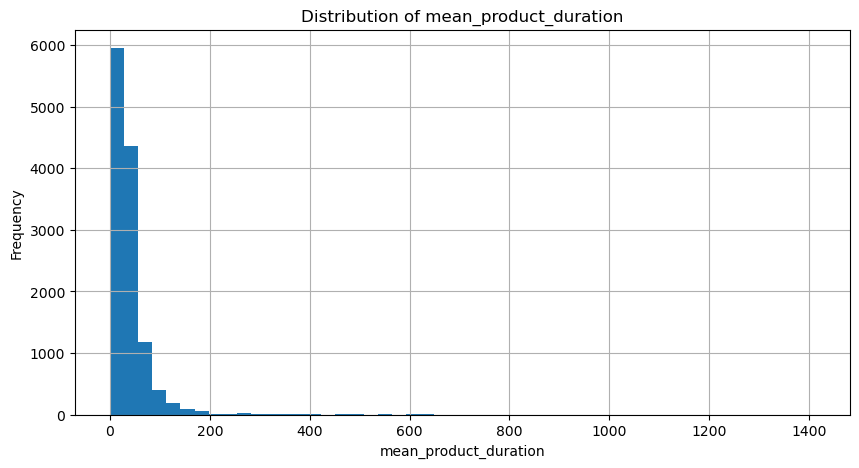

In [462]:
df['mean_product_duration'].hist(bins=50, figsize=(10,5))
plt.xlabel('mean_product_duration')
plt.ylabel('Frequency')
plt.title('Distribution of mean_product_duration')
plt.show()

In [463]:
last_bin_rows = last_bin.sort_values('mean_product_duration', ascending=False).reset_index()
last_bin_rows.head(30)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration
0,536,0,0.00,1,1411.0,1,1411.000000,0.000000,0.100000,0.000000,...,2,2,1,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1411.000000
1,4583,0,0.00,0,0.0,1,1364.000000,0.000000,0.100000,0.000000,...,3,2,4,4,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1364.000000
2,6333,0,0.00,0,0.0,1,1195.800000,0.000000,0.000000,0.000000,...,2,2,7,13,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1195.800000
3,11580,0,0.00,0,0.0,2,1787.500000,0.100000,0.150000,0.000000,...,3,2,3,13,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",893.750000
4,8461,0,0.00,0,0.0,3,2251.280000,0.095833,0.137427,0.000000,...,3,2,1,13,Returning_Visitor,False,False,"(2132.451, 4264.901]","(84.413, 1411.0]",750.426667
5,8426,0,0.00,0,0.0,1,695.500000,0.000000,0.100000,0.000000,...,2,2,4,1,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",695.500000
6,9671,0,0.00,0,0.0,3,1952.500000,0.066667,0.122222,0.000000,...,1,1,2,1,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",650.833333
7,2176,0,0.00,0,0.0,1,643.000000,0.133333,0.150000,0.000000,...,2,2,1,5,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",643.000000
8,488,0,0.00,0,0.0,4,2528.000000,0.000000,0.066667,0.000000,...,2,2,9,1,Returning_Visitor,True,False,"(2132.451, 4264.901]","(84.413, 1411.0]",632.000000
9,3861,0,0.00,0,0.0,1,612.000000,0.000000,0.100000,0.000000,...,1,1,1,3,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",612.000000


Amongst the 30 rows with the highest average product duration, the 20 sessions ended with no purchase, but spanned 7-24 minutes, possibly indicating idle sessions. However the possibility that they are legitimate, engaged sessions is not ruled out, taking into account that some sessions involve visiting 1-4 total product pages, and some visiting other types of pages in the same session.

## Explore Administrative Outliers

In [464]:
# Check all outliers for ProductRelated_Duration
q1 = df['Administrative_Duration'].quantile(0.25)
q3 = df['Administrative_Duration'].quantile(0.75)
IQR = q3 - q1

lower_boundary = q1 - 1.5 * IQR
upper_boundary = q3 + 1.5 * IQR

outliers = df[(df['Administrative_Duration'] < lower_boundary) | (df['Administrative_Duration'] > upper_boundary)]
outliers.shape

(1172, 21)

In [465]:
# Check only right skewed outliers
top_outliers = df[(df['Administrative_Duration'] > upper_boundary)]
top_outliers.shape

(1172, 21)

In [466]:
# Check how many of these sessions led to a purchase
outliers['Revenue'].value_counts(normalize=True)

Revenue
False    0.75256
True     0.24744
Name: proportion, dtype: float64

Informational outliers overall have a higher ratio (~25:100) than the full dataset for sessions with a purchase (15:85)

In [467]:
# Perform similar exploration of administrative and informational durations
df['mean_administrative_duration'] = df['Administrative_Duration'] / df['Administrative']
df['mean_administrative_duration'].describe()

count    6562.000000
mean       37.948819
std        57.460324
min         0.000000
25%        13.600000
50%        23.000000
75%        42.000000
max      1566.600000
Name: mean_administrative_duration, dtype: float64

Like ProductRelated_Duration, Administrative also has an extreme max value compared to 75% of the sessions.

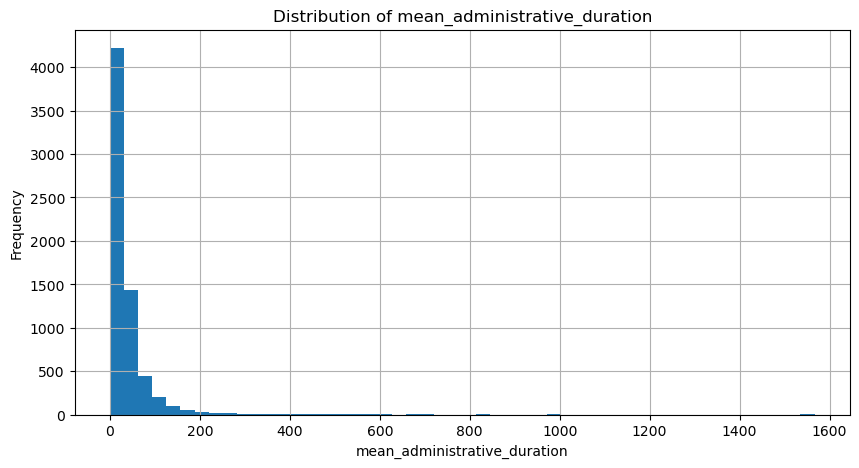

In [468]:
df['mean_administrative_duration'].hist(bins=50, figsize=(10,5))
plt.xlabel('mean_administrative_duration')
plt.ylabel('Frequency')
plt.title('Distribution of mean_administrative_duration')
plt.show()

In [469]:
highest_admin_mean_dur = df.sort_values(by='mean_administrative_duration', ascending=False)
highest_admin_mean_dur.head(30)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration,mean_administrative_duration
5942,1,1566.600000,0,0.000000,34,2256.749540,0.000000,0.000250,0.000000,0.0,...,2,3,2,Returning_Visitor,False,False,"(2132.451, 4264.901]","(61.811, 84.413]",66.374986,1566.600000
224,1,993.000000,0,0.000000,28,1529.304670,0.001481,0.009150,0.000000,0.0,...,2,4,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(50.8, 61.811]",54.618024,993.000000
2446,2,1687.500000,0,0.000000,29,3098.033333,0.000000,0.025806,0.000000,0.0,...,4,5,3,Returning_Visitor,False,False,"(2132.451, 4264.901]","(84.413, 1411.0]",106.828736,843.750000
9633,2,1668.500000,4,35.000000,18,1372.975000,0.000000,0.017391,41.646259,0.0,...,2,1,6,Returning_Visitor,False,True,"(-63.974, 2132.451]","(61.811, 84.413]",76.276389,834.250000
1996,1,702.000000,0,0.000000,38,2193.150794,0.012281,0.015614,9.092772,0.0,...,1,2,2,Returning_Visitor,False,True,"(2132.451, 4264.901]","(50.8, 61.811]",57.714495,702.000000
8071,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,0.0,...,2,1,2,Returning_Visitor,False,False,"(61841.071, 63973.522]","(84.413, 1411.0]",142.480005,679.750000
1336,1,613.666667,0,0.000000,4,957.000000,0.161905,0.096299,0.000000,0.0,...,2,8,10,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",239.250000,613.666667
1351,2,1223.000000,4,416.000000,21,2755.670940,0.004545,0.027576,0.000000,0.0,...,2,1,2,Returning_Visitor,True,False,"(2132.451, 4264.901]","(84.413, 1411.0]",131.222426,611.500000
5004,2,1172.000000,0,0.000000,24,1244.066667,0.008000,0.028000,0.000000,0.0,...,8,2,6,Returning_Visitor,False,False,"(-63.974, 2132.451]","(50.8, 61.811]",51.836111,586.000000
11344,1,585.500000,0,0.000000,80,3634.141512,0.004321,0.007864,26.411138,0.0,...,2,2,2,Returning_Visitor,False,True,"(2132.451, 4264.901]","(43.597, 50.8]",45.426769,585.500000


Within the sessions with the 30 longest average informational page durations, there are sessions with finalized purchases, and no obvious pattern to indicate tabbed out, inactive sessions. 

In [470]:
# Check Revenue outcomes for the highest total administrative duration
max_admin = df.sort_values('Administrative_Duration', ascending=False).reset_index()
max_admin.head(20)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration,mean_administrative_duration
0,8071,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,...,2,1,2,Returning_Visitor,False,False,"(61841.071, 63973.522]","(84.413, 1411.0]",142.480005,679.750000
1,5776,7,2720.500000,3,353.400000,68,5943.547619,0.032237,0.038623,0.000000,...,2,1,13,Returning_Visitor,False,False,"(4264.901, 6397.352]","(84.413, 1411.0]",87.405112,388.642857
2,9238,15,2657.318056,13,1949.166667,343,29970.465970,0.005316,0.028971,0.000000,...,2,1,2,Returning_Visitor,False,False,"(29854.31, 31986.761]","(84.413, 1411.0]",87.377452,177.154537
3,5152,17,2629.253968,24,2050.433333,705,43171.233380,0.004851,0.015431,0.763829,...,2,1,14,Returning_Visitor,True,False,"(42649.015, 44781.466]","(50.8, 61.811]",61.235792,154.661998
4,6165,10,2407.423810,3,434.300000,486,23050.104140,0.000324,0.011249,0.000000,...,2,1,3,Returning_Visitor,False,False,"(21324.507, 23456.958]","(43.597, 50.8]",47.428198,240.742381
5,4884,5,2156.166667,2,92.000000,15,463.000000,0.036364,0.042208,0.000000,...,2,4,4,Returning_Visitor,True,False,"(-63.974, 2132.451]","(30.575, 34.131]",30.866667,431.233333
6,11712,14,2137.112745,0,0.000000,53,4223.409838,0.008772,0.017126,8.886649,...,2,2,2,Returning_Visitor,False,False,"(2132.451, 4264.901]","(61.811, 84.413]",79.686978,152.650910
7,9736,8,2086.750000,1,46.500000,81,5546.000000,0.002326,0.014563,15.564622,...,2,1,2,Returning_Visitor,False,True,"(4264.901, 6397.352]","(61.811, 84.413]",68.469136,260.843750
8,1572,11,2047.234848,9,1146.666667,45,3641.213151,0.002637,0.014311,7.753880,...,2,1,2,Returning_Visitor,False,True,"(2132.451, 4264.901]","(61.811, 84.413]",80.915848,186.112259
9,4509,22,1951.279141,1,99.000000,55,3373.015865,0.016438,0.038293,8.508238,...,2,3,1,Returning_Visitor,False,False,"(2132.451, 4264.901]","(50.8, 61.811]",61.327561,88.694506


The first 5 sessions almost all have extremely disproportionate amount of product pages visited- up to 705 in a session, while having the highest administrative page time and none leading to a purchase. However, the highest administrative time spent was ~1 hour, which is not impossibly long, and besides the few rows with extreme product page durations that have already been decided to be dropped, there is no obvious pattern to suggest impossible sessions.

## Explore Informational

In [471]:
# Check all outliers for ProductRelated_Duration
q1 = df['Informational_Duration'].quantile(0.25)
q3 = df['Informational_Duration'].quantile(0.75)
IQR = q3 - q1

lower_boundary = q1 - 1.5 * IQR
upper_boundary = q3 + 1.5 * IQR

outliers = df[(df['Informational'] < lower_boundary) | (df['Informational_Duration'] > upper_boundary)]
outliers.shape

(2405, 22)

In [472]:
top_outliers = df[(df['Informational_Duration'] > upper_boundary)]
top_outliers.shape

(2405, 22)

The Informational_Duration column has 1000+ more outliers than ProductRelated_Duration and Administrative_Duration.

In [473]:
outliers['Revenue'].value_counts(normalize=True)

Revenue
False    0.765073
True     0.234927
Name: proportion, dtype: float64

In [474]:
df['mean_informational_duration'] = df['Informational_Duration'] / df['Informational']
df['mean_informational_duration'].describe()

count    2631.000000
mean       69.395551
std       127.882397
min         0.000000
25%        12.416667
50%        31.750000
75%        73.466667
max      1778.000000
Name: mean_informational_duration, dtype: float64

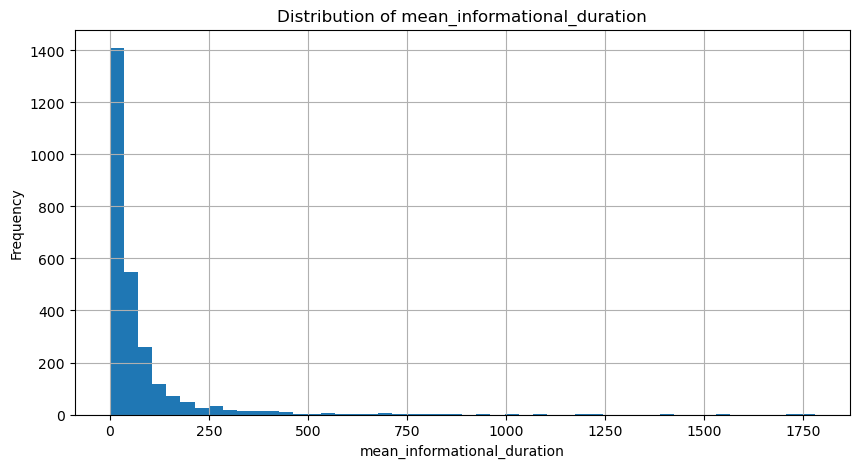

In [475]:
df['mean_informational_duration'].hist(bins=50, figsize=(10,5))
plt.xlabel('mean_informational_duration')
plt.ylabel('Frequency')
plt.title('Distribution of mean_informational_duration')
plt.show()

In [476]:
highest_info_mean_dur = df.sort_values(by='mean_informational_duration', ascending=False)
highest_info_mean_dur.head(30)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration,mean_administrative_duration,mean_informational_duration
4253,3,270.000000,1,1778.000000,362,13259.293960,0.002883,0.008838,0.000000,0.0,...,1,19,Returning_Visitor,True,False,"(12794.704, 14927.155]","(34.131, 38.446]",36.627884,90.000000,1778.000000
9514,0,0.000000,1,1729.000000,19,1401.083333,0.020000,0.050000,0.000000,0.0,...,1,3,Returning_Visitor,False,False,"(-63.974, 2132.451]","(61.811, 84.413]",73.741228,NaN,1729.000000
11214,3,34.000000,1,1530.000000,97,3989.485553,0.002000,0.012202,0.000000,0.0,...,1,3,Returning_Visitor,True,False,"(2132.451, 4264.901]","(38.446, 43.597]",41.128717,11.333333,1530.000000
536,0,0.000000,1,1411.000000,1,1411.000000,0.000000,0.100000,0.000000,0.0,...,1,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1411.000000,NaN,1411.000000
243,0,0.000000,1,1220.000000,28,2389.333333,0.016667,0.030833,0.000000,0.0,...,1,3,Returning_Visitor,True,False,"(2132.451, 4264.901]","(84.413, 1411.0]",85.333333,NaN,1220.000000
9355,4,88.000000,1,1174.000000,173,6014.398401,0.009531,0.025130,1.539318,0.0,...,1,2,Returning_Visitor,True,True,"(4264.901, 6397.352]","(34.131, 38.446]",34.765309,22.000000,1174.000000
11406,7,243.746951,1,1073.000000,33,4931.198912,0.016667,0.028235,25.100433,0.0,...,2,2,Returning_Visitor,False,False,"(4264.901, 6397.352]","(84.413, 1411.0]",149.430270,34.820993,1073.000000
7559,7,107.750000,1,1021.600000,33,1454.750000,0.004762,0.009683,40.189752,0.0,...,1,4,Returning_Visitor,True,False,"(-63.974, 2132.451]","(43.597, 50.8]",44.083333,15.392857,1021.600000
9639,8,388.791667,1,944.750000,17,1464.416667,0.019048,0.034921,0.000000,0.0,...,4,3,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",86.142157,48.598958,944.750000
334,0,0.000000,1,929.000000,75,4105.666667,0.002632,0.017325,0.000000,0.0,...,3,1,Returning_Visitor,False,False,"(2132.451, 4264.901]","(50.8, 61.811]",54.742222,NaN,929.000000


In [477]:
# Check Revenue outcomes for the highest total informational duration
max_info = df.sort_values('Informational_Duration', ascending=False).reset_index()
max_info.head(20)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration,mean_administrative_duration,mean_informational_duration
0,8071,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,...,1,2,Returning_Visitor,False,False,"(61841.071, 63973.522]","(84.413, 1411.0]",142.480005,679.750000,424.895833
1,10302,4,367.000000,5,2256.916667,74,8981.580128,0.002989,0.043302,0.000000,...,1,8,Returning_Visitor,False,False,"(8529.803, 10662.254]","(84.413, 1411.0]",121.372704,91.750000,451.383333
2,6020,8,116.972222,9,2252.033333,19,1135.880556,0.009677,0.011842,0.000000,...,4,2,Returning_Visitor,True,False,"(-63.974, 2132.451]","(50.8, 61.811]",59.783187,14.621528,250.225926
3,5512,3,28.800000,5,2195.300000,21,378.400000,0.029630,0.030864,0.000000,...,3,1,Returning_Visitor,False,False,"(-63.974, 2132.451]","(15.376, 18.449]",18.019048,9.600000,439.060000
4,11470,8,145.100000,6,2166.500000,14,1805.425000,0.000000,0.031138,10.900234,...,1,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",128.958929,18.137500,361.083333
5,5152,17,2629.253968,24,2050.433333,705,43171.233380,0.004851,0.015431,0.763829,...,1,14,Returning_Visitor,True,False,"(42649.015, 44781.466]","(50.8, 61.811]",61.235792,154.661998,85.434722
6,9238,15,2657.318056,13,1949.166667,343,29970.465970,0.005316,0.028971,0.000000,...,1,2,Returning_Visitor,False,False,"(29854.31, 31986.761]","(84.413, 1411.0]",87.377452,177.154537,149.935897
7,8846,0,0.000000,3,1830.500000,81,5000.739116,0.003294,0.020433,0.000000,...,3,2,Returning_Visitor,True,False,"(4264.901, 6397.352]","(50.8, 61.811]",61.737520,NaN,610.166667
8,3574,0,0.000000,9,1779.166667,12,1886.500000,0.007018,0.019298,0.000000,...,6,3,New_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",157.208333,NaN,197.685185
9,4253,3,270.000000,1,1778.000000,362,13259.293960,0.002883,0.008838,0.000000,...,1,19,Returning_Visitor,True,False,"(12794.704, 14927.155]","(34.131, 38.446]",36.627884,90.000000,1778.000000


There is no obvious correlation amongst high total informational duration and Revenue. Theres no uniformity in the number of administrative, informational and product related pages visited, and if this is used alongside ProductRelated_Duration, the bot-like sessions that show up here will already have been removed.

## Variables vs Desired Outcome (Revenue)

In the markdowns following the charts and groupby statements, i use median and mean in selective ways - where there are outliers for the max value of a variable, I use median, and I use either when there are no outliers, since the average wont be pulled by outlier values.

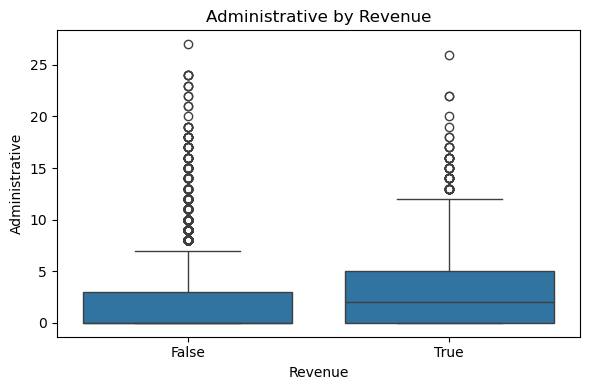

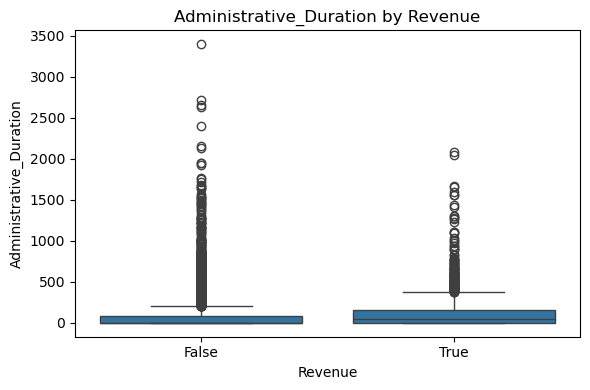

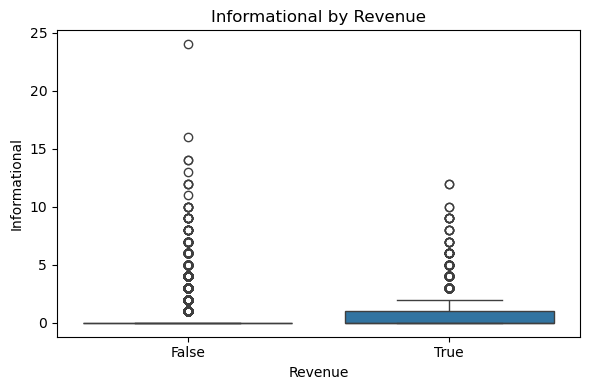

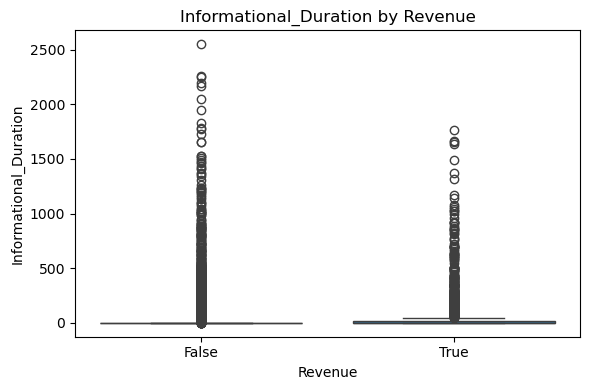

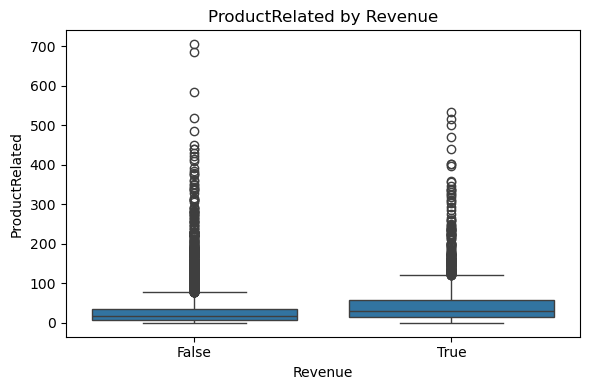

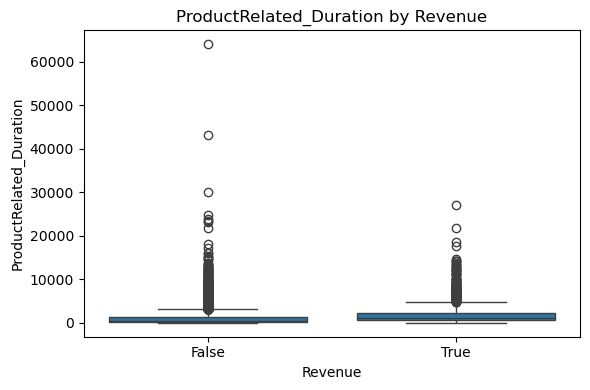

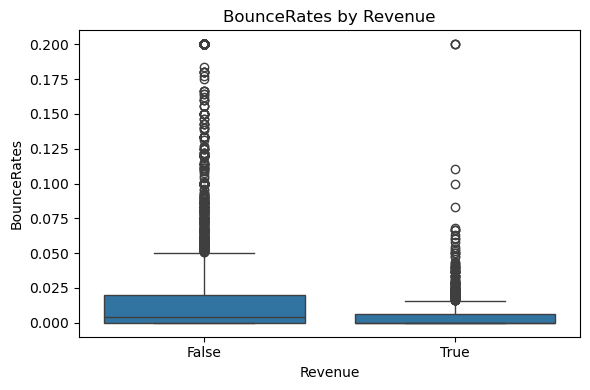

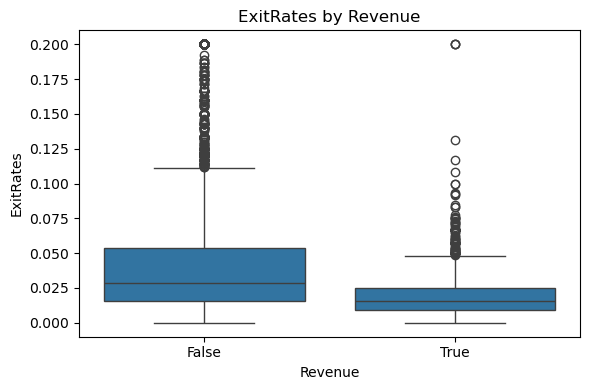

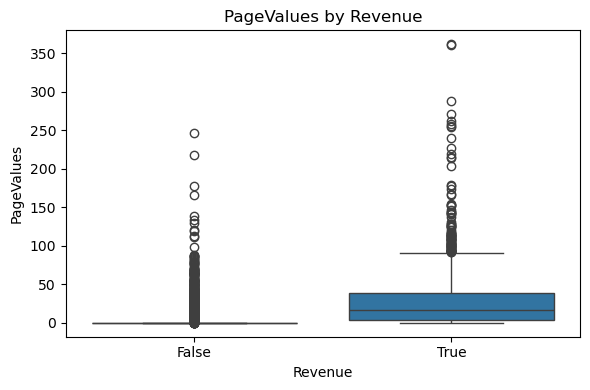

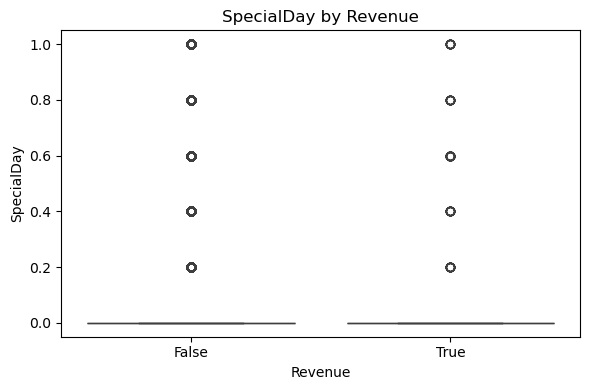

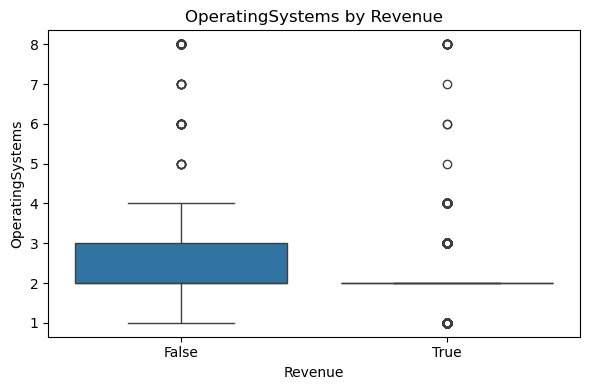

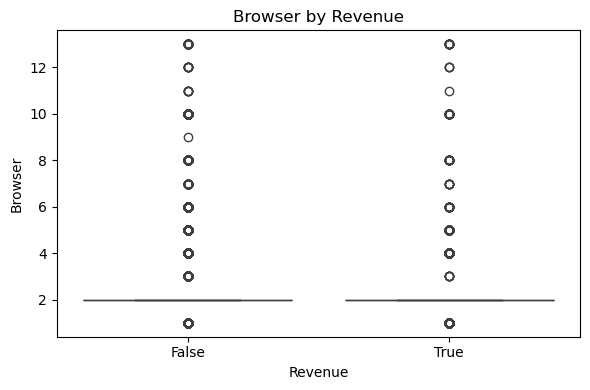

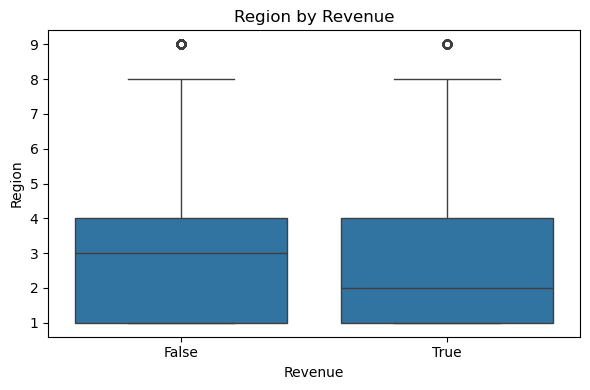

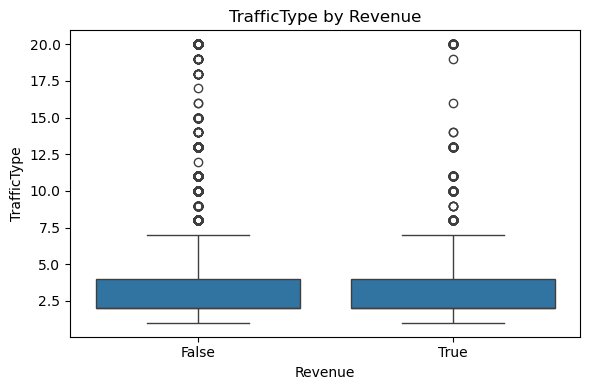

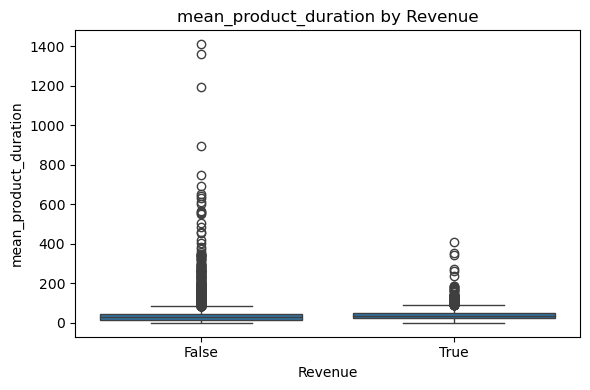

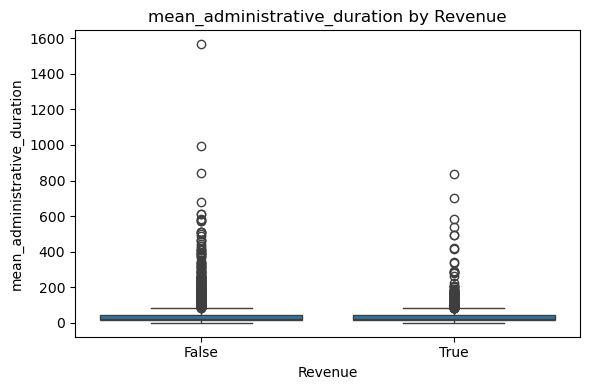

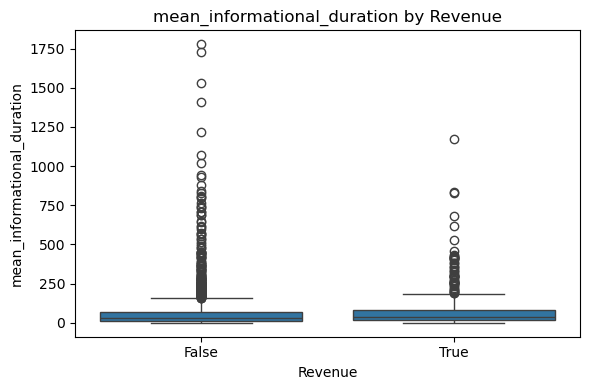

In [478]:
# Preliminary look at numerical variables against the desired outcome variable

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f'{col} by Revenue')
    plt.xlabel('Revenue')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Multiple variables are heavily right-skewed, meaning they'll need to be handled before being utilized in a logistic regression model, which is sensitive to outliers.

In [479]:
df.groupby('Revenue')['ProductRelated'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


The number of product related pages visited in sessions with generated revenue had a median nearly 2x higher than for sessions without revenue.

In [480]:
df.groupby('Revenue')['Administrative'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,2.117732,3.202481,0.0,0.0,0.0,3.0,27.0
True,1908.0,3.393606,3.730527,0.0,0.0,2.0,5.0,26.0


For sessions that did end in a purchase, half of the users visited at least ~2 administrative pages, as opposed to 0 for non-purchase sessions.

In [481]:
df.groupby('Revenue')['Administrative_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,73.740111,171.017970,0.0,0.0,0.000000,83.000000,3398.75
True,1908.0,119.483244,201.114732,0.0,0.0,52.366667,151.083333,2086.75


Pick either Administrative pages or Administrative duration for the logistic regression model - do not use both as they're highly correlated.

Options: Ridge or Lasso regularization for automatic feature selection, or run VIF before and after dropping one of the variables.

Looking at the Informational vs Revenue graph, nearly no one aside from outlier cases visited informational pages, except in sessions with a purchase made - in those, there was a percentage of people who visited at least one. 

In [482]:
df.groupby('Revenue')['Informational'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.451833,1.211582,0.0,0.0,0.0,0.0,24.0
True,1908.0,0.786164,1.521176,0.0,0.0,0.0,1.0,12.0


25% of sessions with a purchase involved the user visiting at least 1 informational page.

In [483]:
df.groupby('Revenue')['Informational_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,30.236237,133.909306,0.0,0.0,0.0,0.0,2549.375000
True,1908.0,57.611427,171.619131,0.0,0.0,0.0,19.0,1767.666667


Informational page visit duration was at 0 for nearly all sessions with no purchase, while at least 25% of sessions with a purchase spent at least 19 seconds on a page.

In [484]:
df.groupby('Revenue')['ProductRelated_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


Product related page visit duration had a median visit take more than 2x longer for sessions with generated revenue.

In [485]:
df.groupby('Revenue')['BounceRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.025317,0.051877,0.0,0.0,0.004255,0.020000,0.2
True,1908.0,0.005117,0.012185,0.0,0.0,0.000000,0.006452,0.2


The average bounce rate is nearly 5x higher for sessions in which a purchase was not made.

In [486]:
df.groupby('Revenue')['ExitRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


Mean exit rates were more than 2x higher for sessions without generated revenue.

In [487]:
df.groupby('Revenue')['PageValues'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


The median page value for sessions with a purchase is 16, compared to 0 for non-purchase sessions. Most sessions that ended with a purchase had non-zero page values, while at least 75% of sessions with no purchase  had page values of *exactly zero*.

PageValues are derived from the revenue pages generate, so intuitively, pages that have high page values will likely lead to more generated revenue, which means they'll show up in our sessions with generated revenue more often. Page values will be a good predictive variable for the model.

In [488]:
df.groupby('Revenue')['SpecialDay'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.068432,0.209054,0.0,0.0,0.0,0.0,1.0
True,1908.0,0.023166,0.123521,0.0,0.0,0.0,0.0,1.0


For sessions where no purchase was made, the average distance to a special day was almost 3 times closer. The actual point value is very small, as the number of days close to a special days are limited.

In [489]:
contingency = pd.crosstab(df['SpecialDay'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

3.5432443403841987e-19


The p value is extremely low, signifying special day and revenue have a statistically significant association.

In [490]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.0882730163013622


Cramer's V is a low value of 0.088, which suggests that SpecialDay's affect on Revenue is weak.

In [518]:
df['SpecialDay'].value_counts()

SpecialDay
0.0    11079
0.6      351
0.8      325
0.4      243
0.2      178
1.0      154
Name: count, dtype: int64

~90% of the 'SpecialDay' values in the dataset are 0, contributing to the low Cramer's v score.

In [519]:
df.groupby('SpecialDay')['Revenue'].agg(['count', 'mean'])

,count,mean
SpecialDay,,
0.0,11079,0.165268
0.2,178,0.078652
0.4,243,0.053498
0.6,351,0.082621
0.8,325,0.033846
1.0,154,0.064935


There is no highly distinct spike in Revenue based on the different values of SpecialDay. However, lasso will regularize this feature according to importance as with the other numerical columns I'm keeping for that step.

In [491]:
pd.crosstab(df['OperatingSystems'],df['Revenue'])

Revenue,False,True
OperatingSystems,,
1,2206,379
2,5446,1155
3,2287,268
4,393,85
5,5,1
6,17,2
7,6,1
8,62,17


OperatingSystems will need to be one hot encoded for the model. 

The most common operating systems used were 1-4, with 1-3 dominating in total usage. OS systems 5, 6, 7, and 8 have too little data to reliably predict off of in a model. They will be kept due to containing other useful variable information, but the OS for those three will be engineered as "other_OS". 

In [492]:
df_OS = df.groupby('OperatingSystems')['Revenue'].mean() * 100
df_OS

OperatingSystems
1    14.661509
2    17.497349
3    10.489237
4    17.782427
5    16.666667
6    10.526316
7    14.285714
8    21.518987
Name: Revenue, dtype: float64

The average number of revenue generating sessions by OS vary between the first 4, most popular systems, with a difference of up to 7 points.

In [493]:
contingency = pd.crosstab(df['OperatingSystems'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

1.4160941129614401e-13


In [494]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.07800589336761586


The p value shows that OperatingSystems and Revenue have a statistically significant association, but Cramer's V value shows that the relationship is weak, being under 0.1. This feature will be dropped.

In [495]:
browser_counts = df['Browser'].value_counts()
browser_counts

Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

The most popular browsers are 1,2,4 and 5, with 2 making up a majority (~65%) of all sessions.

Similarly to the OS variable, browsers 13, 7, 12, 11, and 9 have too little data (chosen here arbitrarily as being under 100 records) to be included in training - high percentage of average occurrences that revenue is generated, when total usage of the browsers is low, can cause over inflated predictions. These browsers should go under an engineered 'other_browser' feature.

In [496]:
df.groupby('Browser')['Revenue'].mean() * 100

Browser
1     14.825345
2     15.362392
3      4.761905
4     17.663043
5     18.415418
6     11.494253
7     12.244898
8     15.555556
9      0.000000
10    19.631902
11    16.666667
12    30.000000
13    26.229508
Name: Revenue, dtype: float64

Besides the least used browsers in the dataset, the average purchase frequency between browsers is not obviously different at a glance.

In [497]:
# Run a statistical test for association
contingency = pd.crosstab(df['Browser'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.00608754317955109


A p value less than 0.05 suggests Revenue is associated with the Browser variable, and differences are unlikely due to random chance.

In [498]:
# Check p value on browsers with records over 100 to see if browsers with less data influenced the p score.
min_count = 100
filtered_browsers = browser_counts[browser_counts > min_count].index

df_filtered = df[df['Browser'].isin(filtered_browsers)]

contingency_filtered = pd.crosstab(df_filtered['Browser'], df_filtered['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency_filtered)

print(p)

0.005239314772361984


The p value is even smaller, indicating Browser does have a non-random association with Revenue.

In [499]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.040433093018440794


Cramer's V value being lower than 0.1 suggests the strength of the relationship between Browser and Revenue is very weak. Browser should be dropped as a feature.

In [500]:
df.groupby('Region')['Revenue'].mean() * 100

Region
1    16.129707
2    16.549296
3    14.523512
4    14.805415
5    16.352201
6    13.913043
7    15.637319
8    12.903226
9    16.829746
Name: Revenue, dtype: float64

Average sessions that generate revenue vary by up to 4 points between regions.

In [501]:
# Run a statistical test for association
contingency = pd.crosstab(df['Region'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.3214249979076556


A p value of more than 0.05 means we fail to reject the null hypothesis, that Region and Revenue are independent of each other. Our value of 0.32 means that Region alone is not significantly associated with Revenue.

In [502]:
df['TrafficType'].nunique()

20

In [503]:
df['TrafficType'].value_counts()

TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

A few types of traffic - 2, 1, 3, and 4, dominate as the most popular - making up ~77% of all traffic types.

Most types of traffic will be lumped under 'other_traffic' for feature building, to keep the number of features down.

In [504]:
df.groupby('TrafficType')['Revenue'].agg(['count', 'mean'])

,count,mean
TrafficType,,
1,2451,0.106895
2,3913,0.216458
3,2052,0.087719
4,1069,0.154350
5,260,0.215385
6,444,0.119369
7,40,0.300000
8,343,0.276968
9,42,0.095238


Traffic type  20 makes up less than 200 sessions in the dataset but 25% of those sessions ended in a purchase- I'll include it, and any traffic with counts higher than traffic type 20.

Traffic types that show up less often than traffic type 20 will be the reference point when one hot encoding, lumped in as "other" traffic.

In [505]:
contingency = pd.crosstab(df['TrafficType'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

1.652735258160153e-67


In [506]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.1739632864587674


Cramer's V shows a weak relationship, but that TrafficType explains *some* variation in Revenue.

In [507]:
df['Month'].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

There's a big difference in the number of sessions each month. 

In [508]:
contingency = pd.crosstab(df['Month'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

2.2387855164805443e-77


An extremely small p value, meaning the two variables have a statistically significant association.

In [509]:
# Check strength of relationship via Cramer's V
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.17669002313952925


Cramer's V shows a weak relationship, but that Month explains *some* variation in Revenue.

In [510]:
# Revenue by Month
df.groupby('Month')['Revenue'].mean() * 100

Month
Aug     17.551963
Dec     12.507238
Feb      1.630435
Jul     15.277778
June    10.069444
Mar     10.068170
May     10.850178
Nov     25.350233
Oct     20.947177
Sep     19.196429
Name: Revenue, dtype: float64

In [511]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [512]:
df.groupby('VisitorType')['Revenue'].mean() * 100

VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

25% of new visitors made a purchase.

While a vast majority of overall sessions are by returning visitors, new visitors are ~1.79x more likely to make a purchase. 'Other' shows a high percentage of purchase, but that group only makes up 85 total sessions in the dataset.

In [513]:
df['Weekend'].value_counts()

Weekend
False    9462
True     2868
Name: count, dtype: int64

In [514]:
df.groupby('Weekend')['Revenue'].mean() * 100

Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64

Weekends show a slightly higher average rate of purchases being made.

In [515]:
contingency = pd.crosstab(df['Weekend'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.0012663251061221968


In [516]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)


0.029029976284465523


Weekends are significantly associated with sessions ending in purchases, however the strength of their relationship is negligible.

## Correlation Heat Map

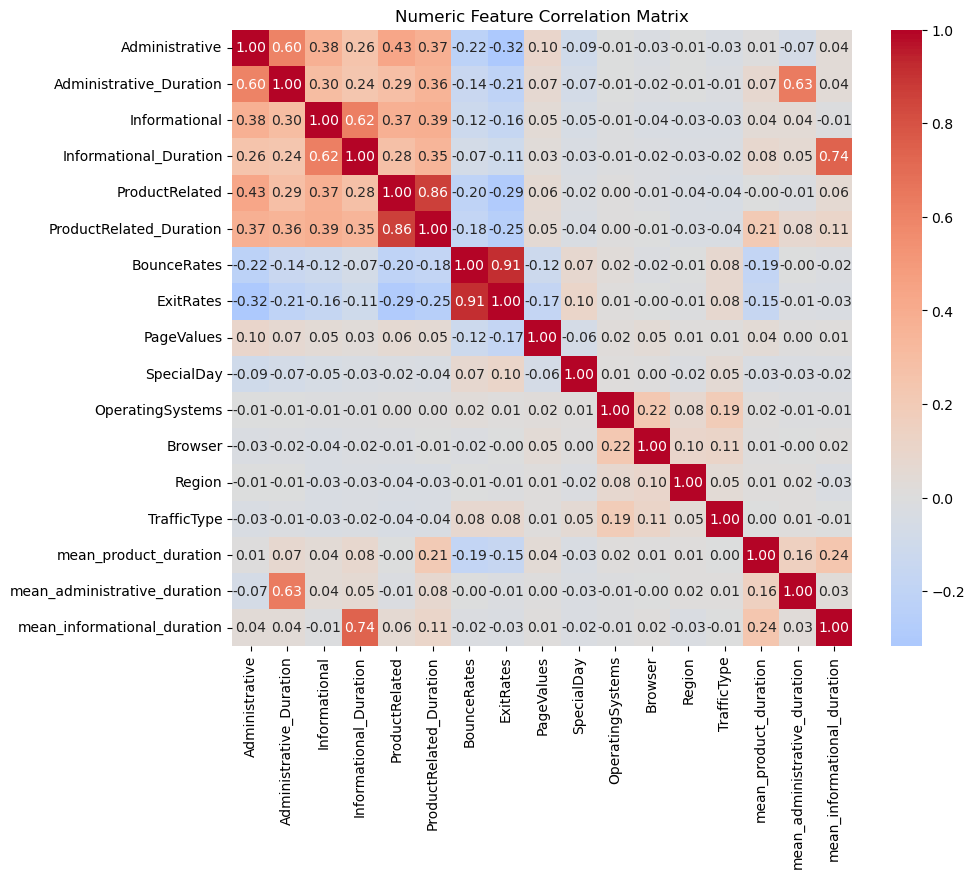

In [517]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr(method='pearson') 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.show()

Exit rates and bounce rates are almost perfectly correlated.

Strong correlations also exist for various pages 

# Findings

The desired outcome variable 'Revenue' is true for 15% of total sessions in the dataset, which will require stratifying the train/test split when modeling, and balancing the class weight, as well as using other metrics beyond accuracy.


The 3 types of pages have visitation durations that are all extremely right skewed, with outliers numbering 1-2k sessions.

These outliers show a higher purchase rate (23-30%) than the purchase rate across the full dataset's sessions (15%).

Average product related page view duration showed an increase in purchase rate with higher view times, up to 60 seconds. Purchase rate declined for longer sessions, which were between 1-24 minutes. With more time, I'd look into this for administrative and informational page durations as well.

For sessions where a purchase was made, users visited each type of page at a higher rate and for a longer time.

While new visitors make up only ~14% of all sessions, they make up 22% of purchases made.

'SpecialDay', 'OperatingSystems', 


## Next Steps for Preprocessing and Cleaning

### Preprocessing Notebooks:
• Drop 'OperatingSystems', 'Browser', 'Region', 'Weekend'.

• Remove the 6 rows with 0 total pages across all 3 types:
df[df['Administrative'] + df['Informational'] + df['ProductRelated'] == 0]

• Drop 3 rows containing the longest ProductRelated_Duration.
• One hot encode TrafficTypes with a count > 100:
• One hot encode 'Month'
• One hot encode 'VisitorType'
• Log transform highly skewed columns

### Modeling Notebook:
• Train/test split
• Standardize columns
• group-lasso columns
